In [1]:
library(tidyverse) # metapackage of all tidyverse packages

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
fig <- function(width, height){
     options(repr.plot.width = width, repr.plot.height = height)
}
fig(10, 10)
theme_set(theme(text=element_text(size=24)))

In [60]:
scopa = read_csv("../CardStock/output/Scopa/2/RndandAI-choicestats.txt")

Rows: 3600 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): game, type
dbl (6): numPlayers, iteration, move, player, choices, choice

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [61]:
scopa

game,numPlayers,type,iteration,move,player,choices,choice
<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Scopa,2,RndandAI,0,0,0,5,1
Scopa,2,RndandAI,0,1,1,3,0
Scopa,2,RndandAI,0,2,0,2,1
Scopa,2,RndandAI,0,3,1,2,1
Scopa,2,RndandAI,0,4,0,1,0
Scopa,2,RndandAI,0,5,1,1,0
Scopa,2,RndandAI,0,6,1,3,1
Scopa,2,RndandAI,0,7,0,3,0
Scopa,2,RndandAI,0,8,1,2,0


`geom_smooth()` using formula = 'y ~ x'


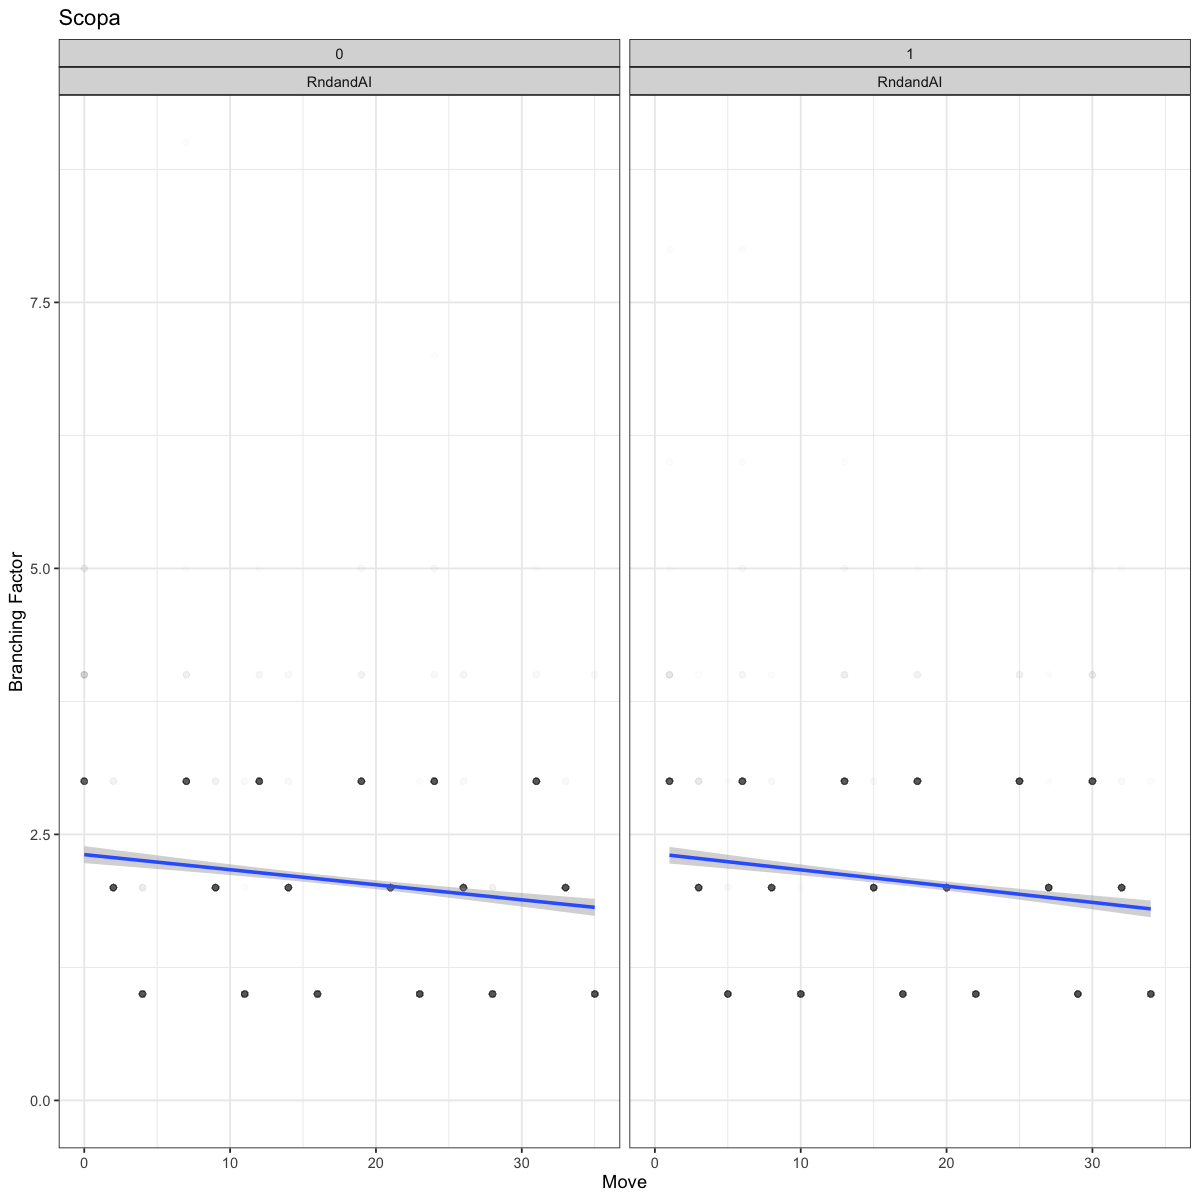

In [65]:
game = "Scopa"
scopa %>% ggplot(aes(x=move, y=choices)) +
geom_point(alpha= 0.01) +
geom_smooth(method="lm") +
facet_wrap(vars(player, type), ncol = 3) +
theme_bw() +
aes(ymin=0) +
labs(x='Move', y='Branching Factor', title=game)

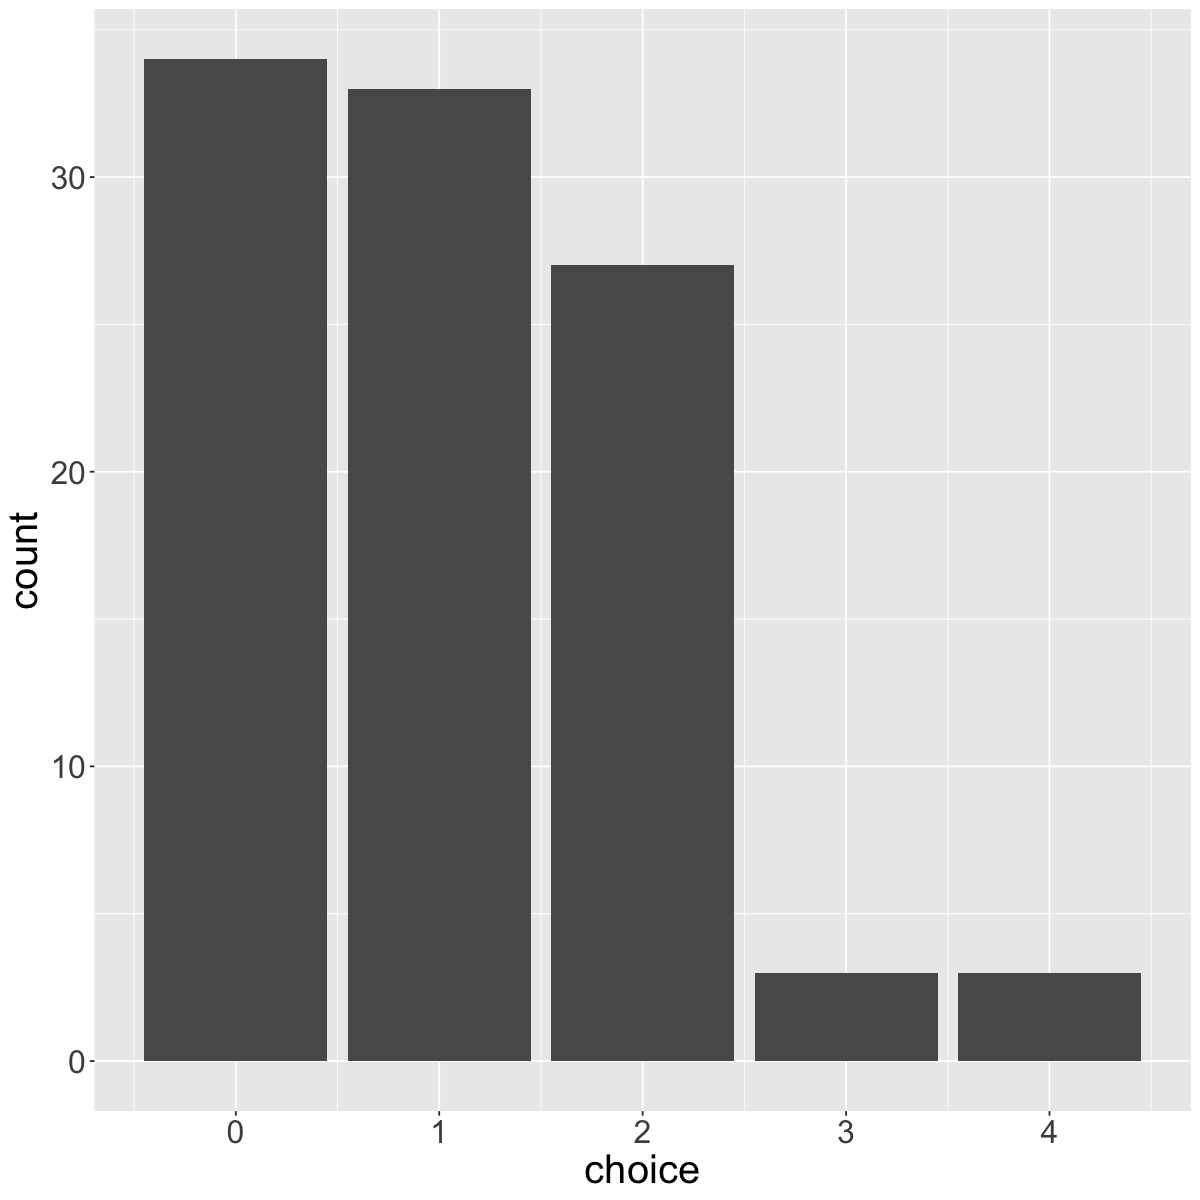

In [64]:
game = "GOPS"
gops %>% filter(move==0) %>% filter(player==0) %>% ggplot(aes(x=choice)) +
geom_bar()

In [52]:
scopa = read_csv("../CardStock/output/Scopa/2/AllRnd-resultsstats.txt")

Rows: 200 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): game, type
dbl (5): numPlayers, iteration, player, score, rank

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [53]:
scopa

game,numPlayers,type,iteration,player,score,rank
<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Scopa,2,AllRnd,0,0,0.03,0.00
Scopa,2,AllRnd,1,0,0.02,0.01
Scopa,2,AllRnd,2,0,0.04,0.00
Scopa,2,AllRnd,3,0,0.02,0.00
Scopa,2,AllRnd,4,0,0.03,0.00
Scopa,2,AllRnd,5,0,0.02,0.00
Scopa,2,AllRnd,6,0,0.03,0.00
Scopa,2,AllRnd,7,0,0.04,0.00
Scopa,2,AllRnd,8,0,0.01,0.01


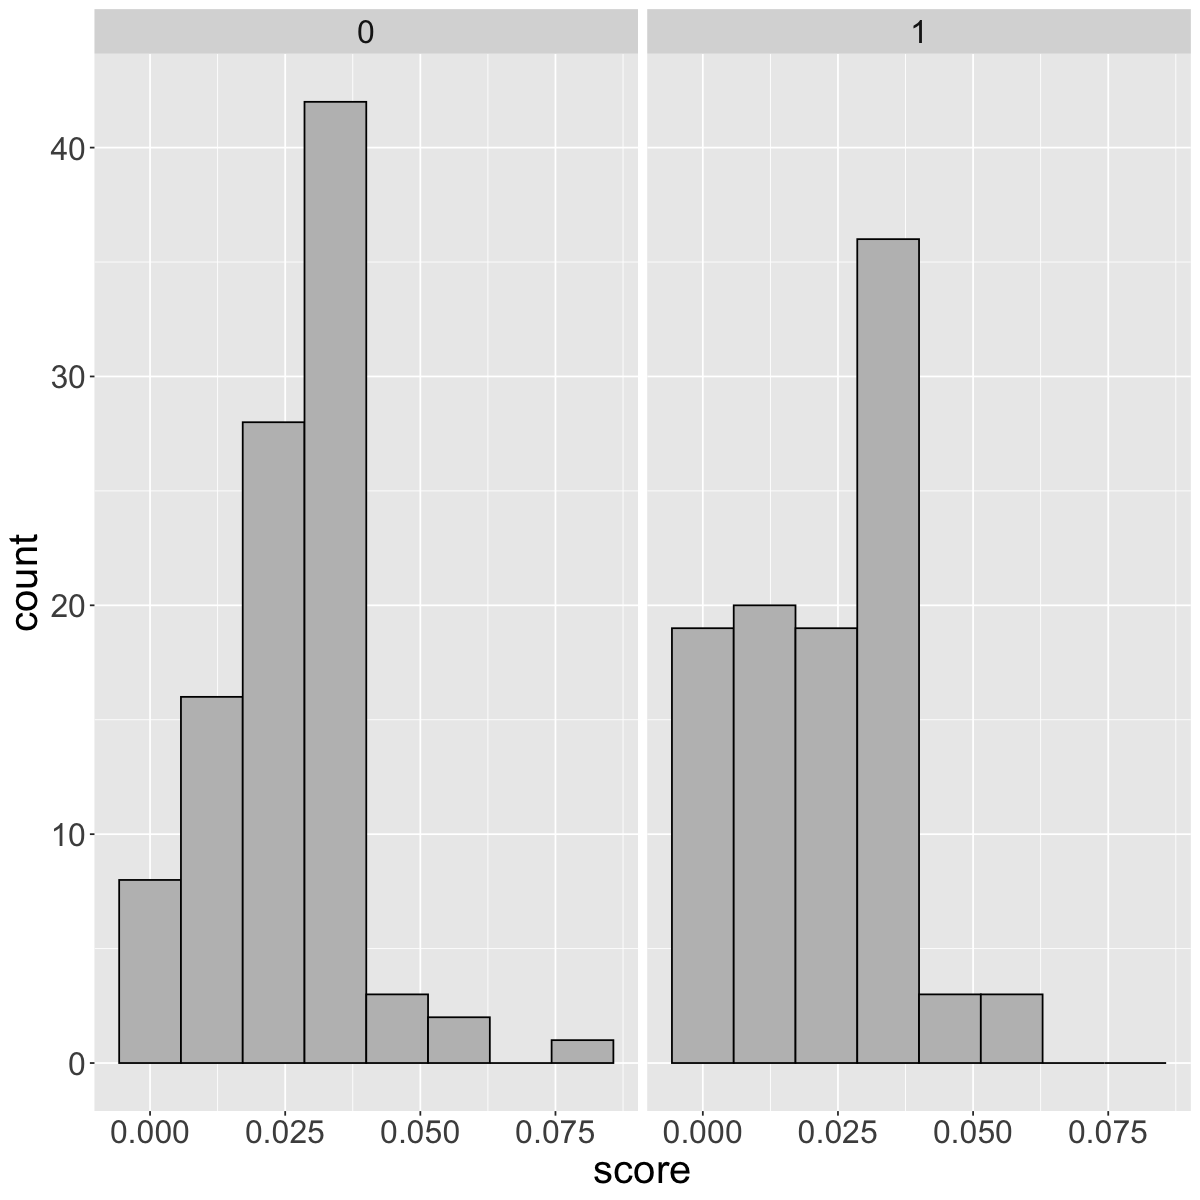

In [54]:
scopa %>% ggplot(aes(x=score)) + 
geom_histogram(bins = 8, color="black", fill="grey") + 
facet_wrap(vars(player))

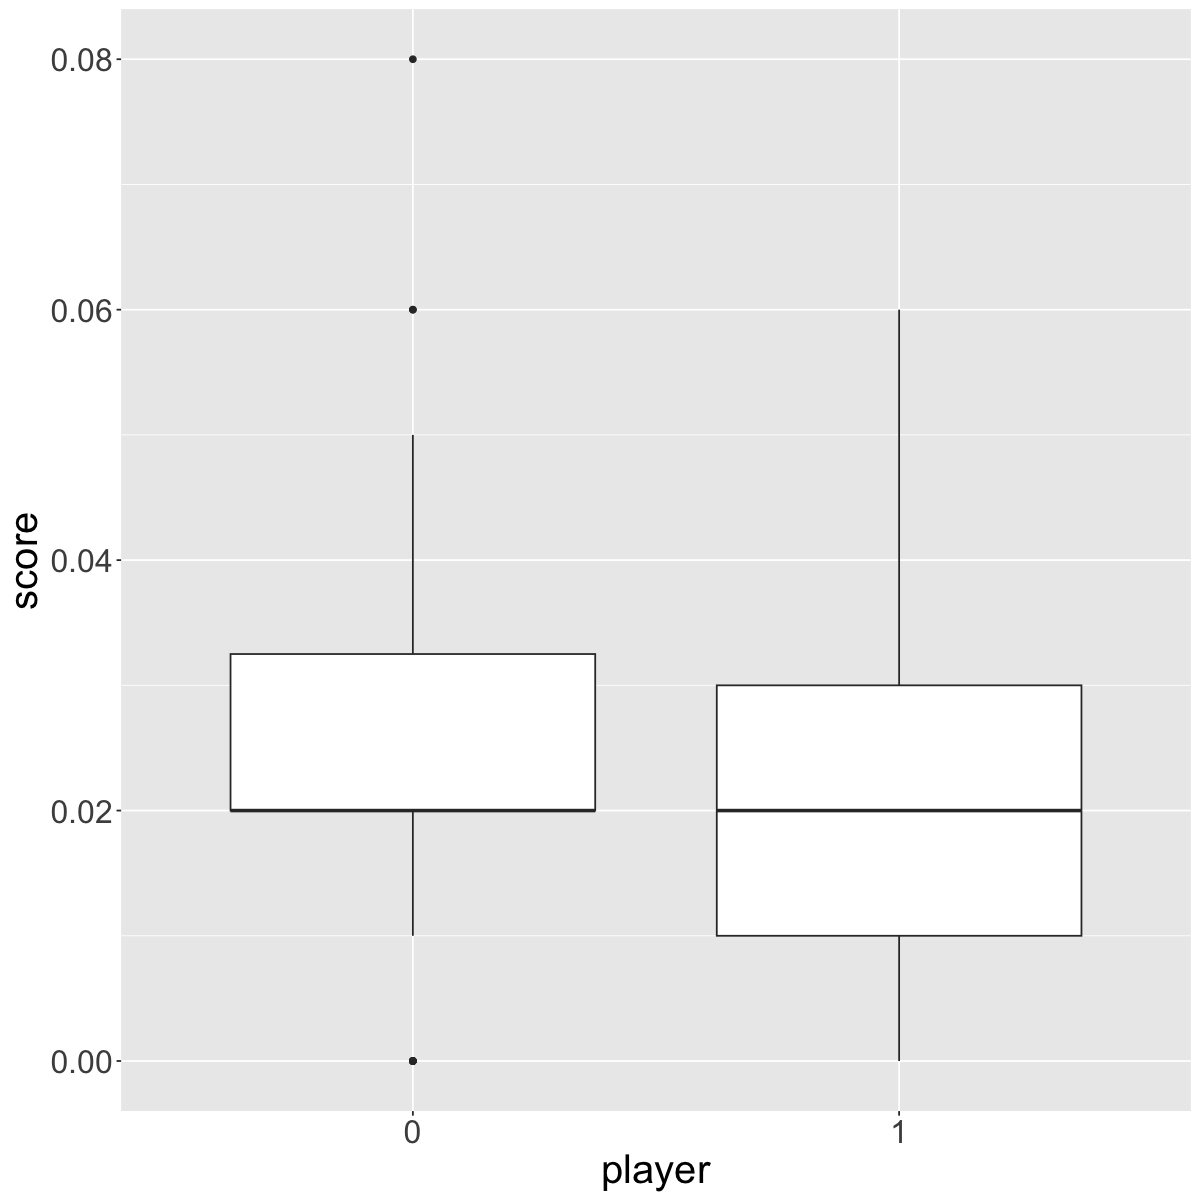

In [55]:
scopa <- scopa %>%
  mutate(player = replace(player, player ==  0, "0"))
scopa <- scopa %>%
  mutate(player = replace(player, player ==  1, "1"))

scopa %>% ggplot(aes(x=player, y=score)) + 
geom_boxplot()

In [59]:
scopa %>% t.test(score ~ player, data = ., alternative="two.sided")



	Welch Two Sample t-test

data:  score by player
t = 1.7023, df = 196.72, p-value = 0.09028
alternative hypothesis: true difference in means between group 0 and group 1 is not equal to 0
95 percent confidence interval:
 -0.0005864615  0.0079864615
sample estimates:
mean in group 0 mean in group 1 
         0.0252          0.0215 
